Gated Recurrent Units (GRUs) are simplified LSTMs. Instead of three gates like in LSTM only two gates are used.
Reset Gate, Update Gate


1. Calculate the Reset and Update Gates at time t
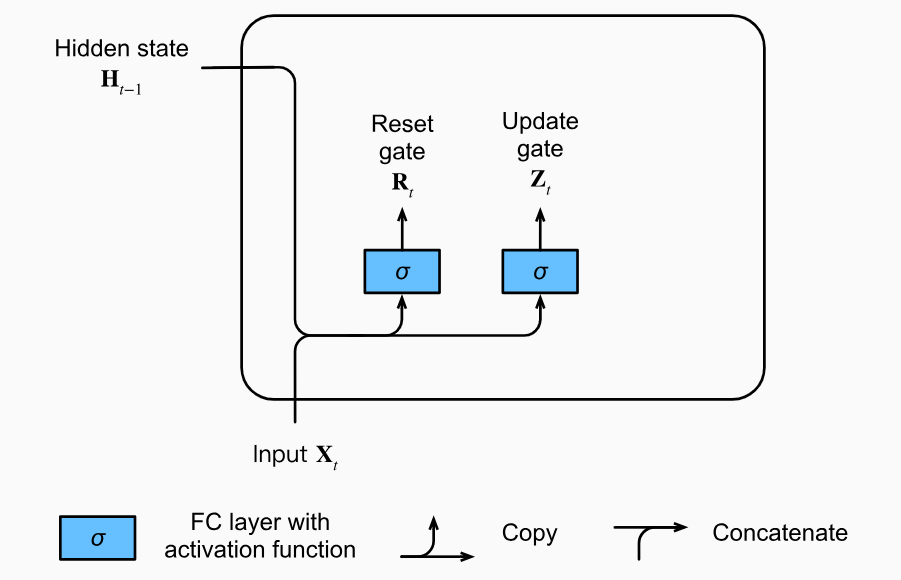

Rt = sigmoid(Xt @ Wxr + Ht-1 @ Whr + br)
Zt = sigmoid(Xt @ Wxz + Ht-1 @ Whz + bz)

Xt - n x d matrix
Ht-1 - n x h matrix

Wxr, Exz - d x h matrix
Whr, Whz - h x h matrix
br, br - h vector

Rt, Zt - n x h matrix 

2. Calculate candidate Hidden State at t
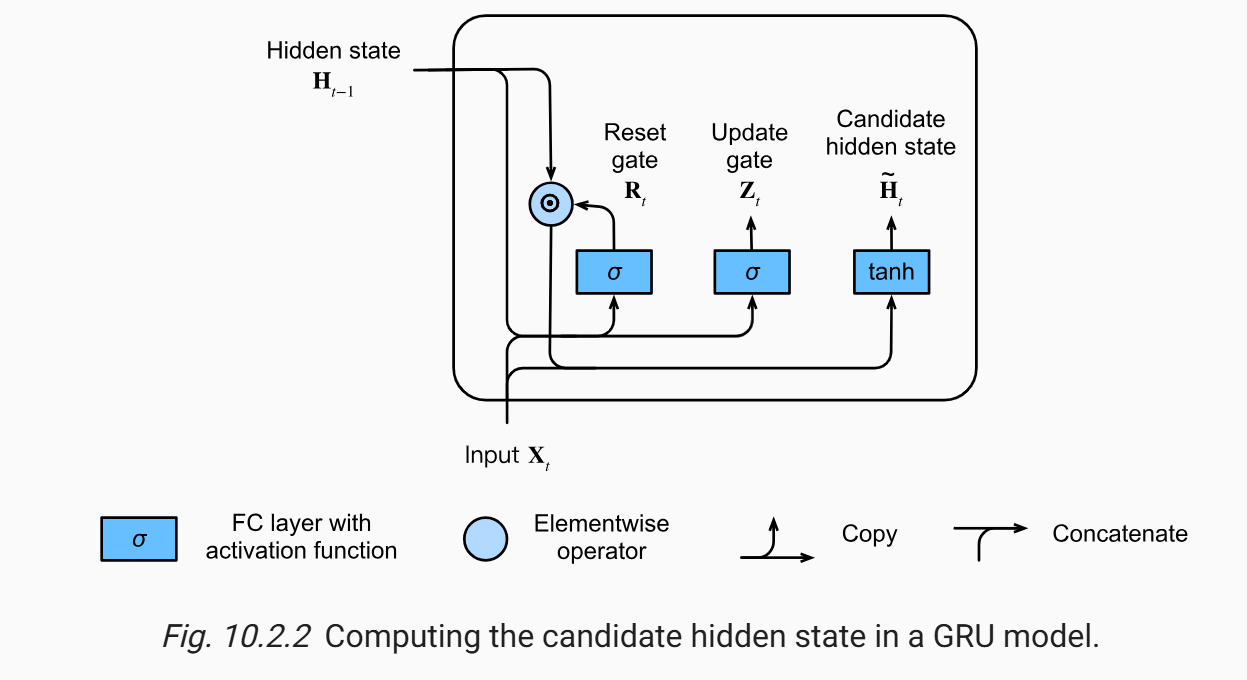

H~t = tanh(Xt @ Wxh + (Rt * Ht-1) @ Whh + bh)

Wxh - d x h matrix
Whh - h xh matrix
bh - h vector

3. Calculate Hidden State Ht
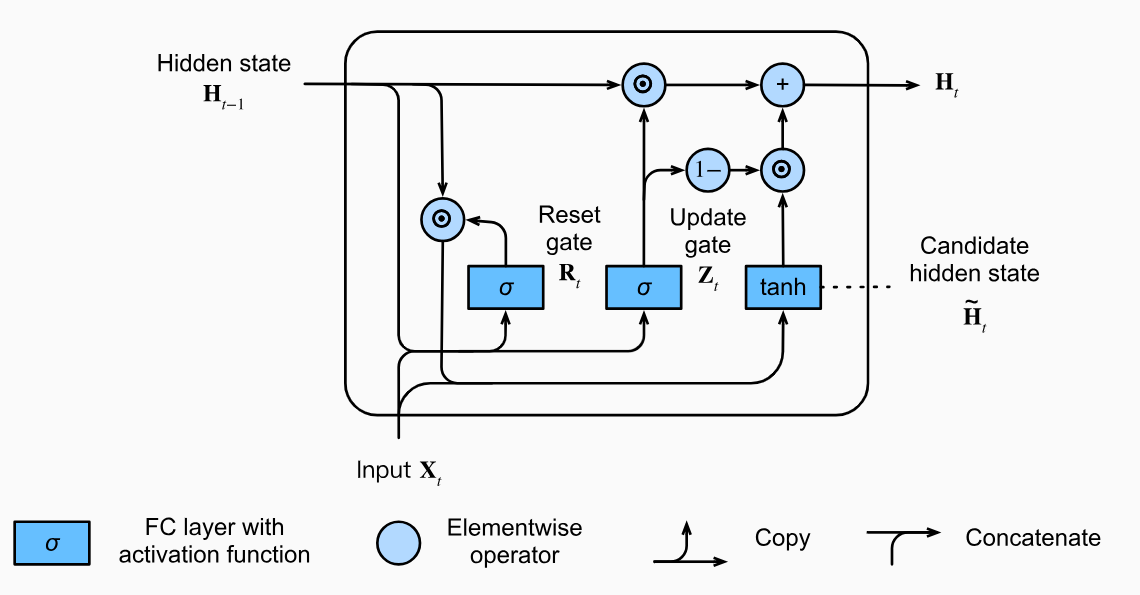

Ht = Zt * Ht-1 + (1 - Zt) * H~t

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
class GRUScratch(d2l.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()

        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)

        triple = lambda: (init_weight(num_inputs, num_hiddens),
            init_weight(num_hiddens, num_hiddens),
            nn.Parameter(torch.zeros(num_hiddens)))

        self.W_xz, self.W_hz, self. b_z = triple() #Update gate parameters
        self.W_xr, self.W_hr, self. b_r = triple() #Forget gate parameters
        self.W_xh, self.W_hh, self. b_h = triple() #Candidate hidden gate parameters

    def forward(self, inputs, H=None):
        if H is None:
            H = torch.zeros((inputs.shape[1], self.num_hiddens))

        outputs = []
        for X in inputs:
            Z = torch.sigmoid(torch.matmul(X, self.W_xz) + torch.matmul(H, self.W_hz) + self.b_z)
            R = torch.sigmoid(torch.matmul(X, self.W_xr) + torch.matmul(H, self.W_hr) + self.b_r)
            H_tilde = torch.tanh(torch.matmul(X, self.W_xh) + torch.matmul(R * H, self.W_hh) + self.b_h)

            H = Z * H + (1-Z) * H_tilde
            outputs.append(H)
        return outputs, H        
         

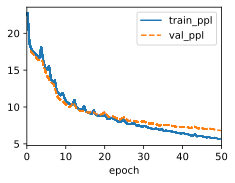

In [3]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
gru = GRUScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = d2l.RNNLMScratch(gru, vocab_size=len(data.vocab), lr=4)
trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

In [4]:
# Concise Implementation
class GRU(d2l.RNN):
    def __init__(self, num_inputs, num_hiddens):
        d2l.Module.__init__(self)
        self.save_hyperparameters()
        self.rnn = nn.GRU(num_inputs, num_hiddens)

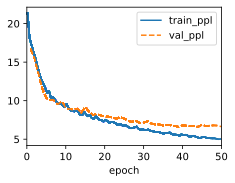

In [5]:
gru = GRU(num_inputs=len(data.vocab), num_hiddens=32)
model = d2l.RNNLM(gru, vocab_size=len(data.vocab), lr=4)
trainer.fit(model, data)

In [6]:
model.predict('it has', 20, data.vocab)

'it has in the that that th'